In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [30]:
EPSILON= 1e-8

Part 1- Dataset Generation

In [13]:
N=3000
x1= np.random.uniform(-2,2,N)
x2= np.random.uniform(-2,2,N)
y = ((x1**2 + x2**2) > 1.5).astype(float).reshape(-1,1)

In [17]:
X= np.column_stack([x1, x2])

Train / Val / Test Split (70/15/15)

In [23]:
def split_data(X,y, train_ratio=0.7, val_ratio=0.15):
    N = len(X)
    idx= np.random.permutation(N)
    train_end = int(N*train_ratio)
    val_end = int(N* (train_ratio + val_ratio))
    
    train_idx = idx[:train_end]
    val_idx = idx[train_end: val_end]
    test_idx = idx[val_end:]
    
    return (X[train_idx], y[train_idx], X[val_idx], y[val_idx],X[test_idx], y[test_idx])

X_train, y_train, X_val, y_val, X_test, y_test= split_data(X,y)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 2100
Val size: 450
Test size: 450


Visualizing the dataset

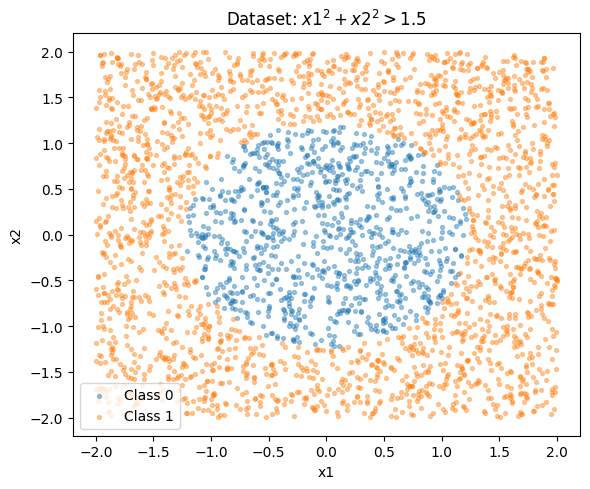

In [28]:
plt.figure(figsize=(6,5))
plt.scatter(x1[y.flatten()==0], x2[y.flatten()==0], s=8, alpha=0.4, label='Class 0')
plt.scatter(x1[y.flatten()==1], x2[y.flatten()==1], s=8, alpha=0.4, label= 'Class 1')
plt.title("Dataset: $x1^2 + x2^2 > 1.5$")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.tight_layout(); plt.show()

Activation Functions

In [29]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z,-500,500)))

def sigmoid_derivative(a):
    return a*(1.0-a)

def relu(z):
    return np.maximum(0,z)

def relu_derivative(a):
    return (a>0).astype(float)

Loss- Binary Cross Entropy

In [31]:
def bce_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, EPSILON, 1 - EPSILON)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


## Metrics & Utility Functions

In [ ]:

def accuracy(y_pred, y_true):
    return np.mean((y_pred >= 0.5).astype(float) == y_true)

# frobenius norm of gradient matrix
def frobenius_norm(grad_W):
    return np.sqrt(np.sum(grad_W ** 2))

def plot_history(history, title, save=True):
    import os
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(title + ' - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title(title + ' - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    if save:
        os.makedirs('plots', exist_ok=True)
        plt.savefig('plots/' + title + '.png', dpi=100)
    plt.show()


Metrics & utilities defined.


## PART 1 — Task 1A: Build Three Dense Architectures (2 / 5 / 10 layers)
### Task 1B: Parameter Counting
**Formula per layer:**  `params = (n_in × n_out) + n_out`

**2-layer** `[2→16→1]`:  
- Layer 1: (2×16)+16 = 48  
- Layer 2: (16×1)+1  = 17  
- **Total = 65**

**5-layer** `[2→16→16→16→16→1]`:  
- Layer 1: 48 | Layer 2-4: (16×16)+16 = 272 each | Layer 5: 17  
- **Total = 48 + 3×272 + 17 = 881**

**10-layer** `[2→16×9→1]`:  
- Layer 1: 48 | Layers 2-9: 272 each (×8) | Layer 10: 17  
- **Total = 48 + 8×272 + 17 = 2241**

In [ ]:

class DenseNetwork:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.weights = []
        self.biases = []
        self.grad_weights = []
        self.grad_biases = []
        self._init_params()

    def _init_params(self):
        for i in range(len(self.layer_sizes) - 1):
            n_in = self.layer_sizes[i]
            n_out = self.layer_sizes[i + 1]
            # He init for relu, Xavier for sigmoid
            if self.activation == 'relu':
                scale = np.sqrt(2.0 / n_in)
            else:
                scale = np.sqrt(1.0 / n_in)
            self.weights.append(np.random.randn(n_in, n_out) * scale)
            self.biases.append(np.zeros((1, n_out)))

    def count_parameters(self):
        total = 0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            p = W.size + b.size
            total += p
            print(f'Layer {i+1}: W{W.shape} + b{b.shape} = {p}')
        print(f'Total params: {total}')
        return total

    def forward(self, X):
        self.activations = [X]
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = self.activations[-1] @ W + b
            is_last = (i == len(self.weights) - 1)
            if is_last:
                a = sigmoid(z)
            elif self.activation == 'sigmoid':
                a = sigmoid(z)
            else:
                a = relu(z)
            self.activations.append(a)
        return self.activations[-1]

    def backward(self, y_true):
        m = y_true.shape[0]
        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)

        # for BCE + sigmoid output, delta = (y_hat - y) / m
        delta = (self.activations[-1] - y_true) / m

        for i in reversed(range(len(self.weights))):
            grad_weights[i] = self.activations[i].T @ delta
            grad_biases[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = delta @ self.weights[i].T
                if self.activation == 'sigmoid':
                    delta = delta * sigmoid_derivative(self.activations[i])
                else:
                    delta = delta * relu_derivative(self.activations[i])

        self.grad_weights = grad_weights
        self.grad_biases = grad_biases
        return grad_weights, grad_biases

    def get_gradient_norms(self):
        return [frobenius_norm(gW) for gW in self.grad_weights]


DenseNetwork class defined.


## Task 1C — Optimizers: SGD, Momentum, Adam

In [ ]:

class SGD:
    def __init__(self, lr=0.05):
        self.lr = lr

    def update(self, net, grad_weights, grad_biases):
        for i in range(len(net.weights)):
            net.weights[i] -= self.lr * grad_weights[i]
            net.biases[i] -= self.lr * grad_biases[i]


class MomentumSGD:
    def __init__(self, lr=0.05, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.vW = None
        self.vb = None

    def update(self, net, grad_weights, grad_biases):
        if self.vW is None:
            self.vW = [np.zeros_like(w) for w in net.weights]
            self.vb = [np.zeros_like(b) for b in net.biases]
        for i in range(len(net.weights)):
            # v = beta*v + lr*grad
            self.vW[i] = self.beta * self.vW[i] + self.lr * grad_weights[i]
            self.vb[i] = self.beta * self.vb[i] + self.lr * grad_biases[i]
            net.weights[i] -= self.vW[i]
            net.biases[i] -= self.vb[i]


class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.mW = self.vW = self.mb = self.vb = None
        self.t = 0

    def update(self, net, grad_weights, grad_biases):
        if self.mW is None:
            self.mW = [np.zeros_like(w) for w in net.weights]
            self.vW = [np.zeros_like(w) for w in net.weights]
            self.mb = [np.zeros_like(b) for b in net.biases]
            self.vb = [np.zeros_like(b) for b in net.biases]
        self.t += 1
        for i in range(len(net.weights)):
            self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * grad_weights[i]
            self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * grad_weights[i]**2
            m_hat = self.mW[i] / (1 - self.beta1**self.t)
            v_hat = self.vW[i] / (1 - self.beta2**self.t)
            net.weights[i] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

            self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * grad_biases[i]
            self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * grad_biases[i]**2
            mb_hat = self.mb[i] / (1 - self.beta1**self.t)
            vb_hat = self.vb[i] / (1 - self.beta2**self.t)
            net.biases[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)


Optimizers defined: SGD, MomentumSGD, Adam


## Training Loop

In [ ]:

def train_model(net, optimizer, X_tr, y_tr, X_vl, y_vl,
                epochs=200, batch_size=64, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'grad_norms': []}
    N = X_tr.shape[0]

    for epoch in range(epochs):
        # shuffle each epoch
        idx = np.random.permutation(N)
        Xs, ys = X_tr[idx], y_tr[idx]

        for start in range(0, N, batch_size):
            Xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            net.forward(Xb)
            gW, gb = net.backward(yb)
            optimizer.update(net, gW, gb)

        # evaluate on full train and val sets
        yp_tr = net.forward(X_tr)
        yp_vl = net.forward(X_vl)
        tl = bce_loss(yp_tr, y_tr)
        vl = bce_loss(yp_vl, y_vl)
        ta = accuracy(yp_tr, y_tr)
        va = accuracy(yp_vl, y_vl)

        # gradient norms using a mini batch
        net.forward(X_tr[:batch_size])
        net.backward(y_tr[:batch_size])
        norms = net.get_gradient_norms()

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['grad_norms'].append(norms)

        if verbose and (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1} | train_loss={tl:.4f} val_loss={vl:.4f} | train_acc={ta:.4f} val_acc={va:.4f}')

    return history


def evaluate_model(net, X_test, y_test, label='Test'):
    yp = net.forward(X_test)
    l = bce_loss(yp, y_test)
    a = accuracy(yp, y_test)
    print(f'{label} -> loss={l:.4f}  acc={a:.4f}')
    return l, a


Training loop defined.


## Task 1A + 1C — Train All 12 Models (3 architectures × 2 activations × 2 optimizers)


  2-layer_sigmoid_SGD

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 65
  Epoch  50 | TrLoss=0.5999 VaLoss=0.6391 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 100 | TrLoss=0.5381 VaLoss=0.5733 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 150 | TrLoss=0.3936 VaLoss=0.4193 | TrAcc=0.8662 VaAcc=0.8378
  Epoch 200 | TrLoss=0.2645 VaLoss=0.2771 | TrAcc=0.9305 VaAcc=0.9356
  [Test] Loss=0.2691  Acc=0.9356


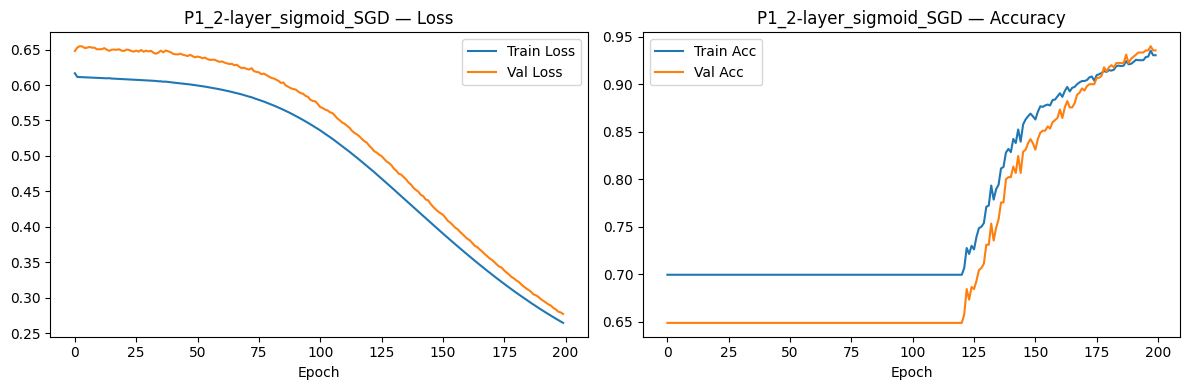


  2-layer_sigmoid_Momentum

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 65
  Epoch  50 | TrLoss=0.0989 VaLoss=0.0959 | TrAcc=0.9862 VaAcc=0.9844
  Epoch 100 | TrLoss=0.0585 VaLoss=0.0602 | TrAcc=0.9962 VaAcc=0.9889
  Epoch 150 | TrLoss=0.0463 VaLoss=0.0490 | TrAcc=0.9962 VaAcc=0.9911
  Epoch 200 | TrLoss=0.0398 VaLoss=0.0429 | TrAcc=0.9962 VaAcc=0.9911
  [Test] Loss=0.0462  Acc=0.9933


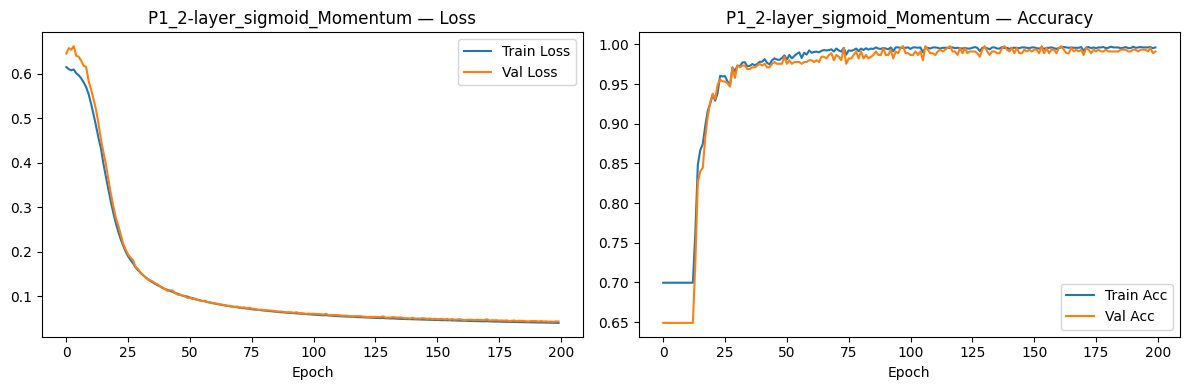


  2-layer_relu_SGD

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 65
  Epoch  50 | TrLoss=0.1120 VaLoss=0.1096 | TrAcc=0.9790 VaAcc=0.9800
  Epoch 100 | TrLoss=0.0734 VaLoss=0.0741 | TrAcc=0.9890 VaAcc=0.9800
  Epoch 150 | TrLoss=0.0576 VaLoss=0.0601 | TrAcc=0.9905 VaAcc=0.9867
  Epoch 200 | TrLoss=0.0486 VaLoss=0.0520 | TrAcc=0.9948 VaAcc=0.9889
  [Test] Loss=0.0575  Acc=0.9933


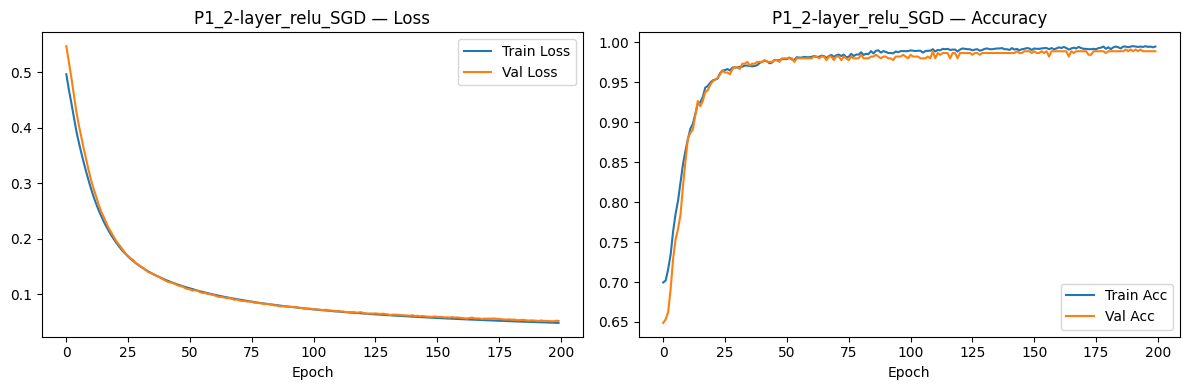


  2-layer_relu_Momentum

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 65
  Epoch  50 | TrLoss=0.0308 VaLoss=0.0345 | TrAcc=0.9948 VaAcc=0.9933
  Epoch 100 | TrLoss=0.0227 VaLoss=0.0303 | TrAcc=0.9929 VaAcc=0.9867
  Epoch 150 | TrLoss=0.0159 VaLoss=0.0236 | TrAcc=0.9967 VaAcc=0.9933
  Epoch 200 | TrLoss=0.0148 VaLoss=0.0226 | TrAcc=0.9943 VaAcc=0.9911
  [Test] Loss=0.0254  Acc=0.9844


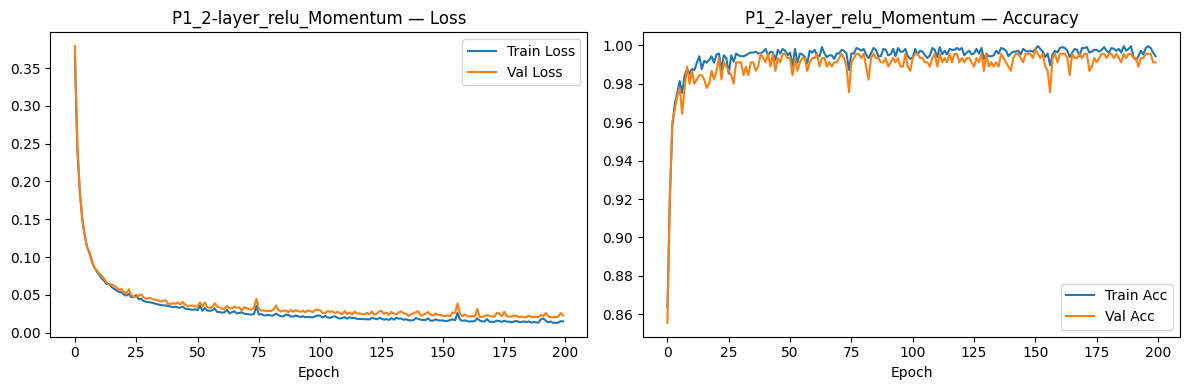


  5-layer_sigmoid_SGD

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 881
  Epoch  50 | TrLoss=0.6113 VaLoss=0.6529 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 100 | TrLoss=0.6113 VaLoss=0.6534 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 150 | TrLoss=0.6114 VaLoss=0.6561 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 200 | TrLoss=0.6113 VaLoss=0.6545 | TrAcc=0.6995 VaAcc=0.6489
  [Test] Loss=0.6090  Acc=0.7022


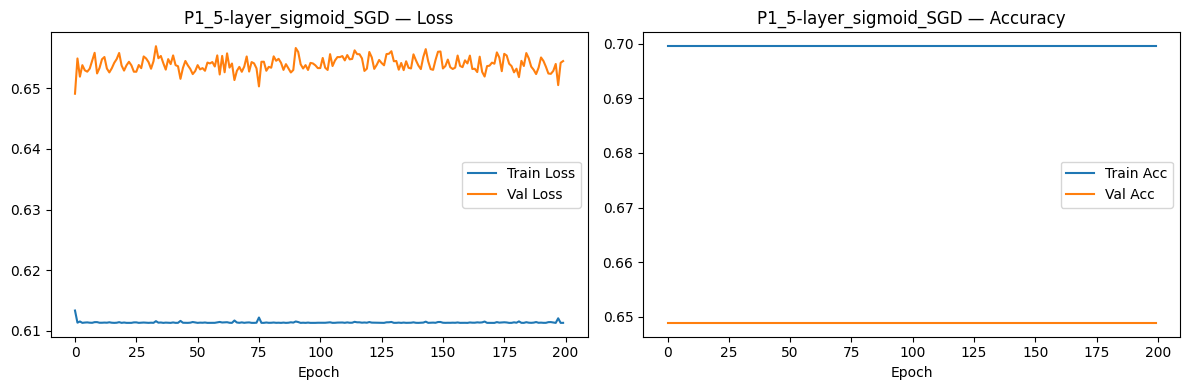


  5-layer_sigmoid_Momentum

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 881
  Epoch  50 | TrLoss=0.6127 VaLoss=0.6496 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 100 | TrLoss=0.6119 VaLoss=0.6508 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 150 | TrLoss=0.6122 VaLoss=0.6600 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 200 | TrLoss=0.6116 VaLoss=0.6574 | TrAcc=0.6995 VaAcc=0.6489
  [Test] Loss=0.6092  Acc=0.7022


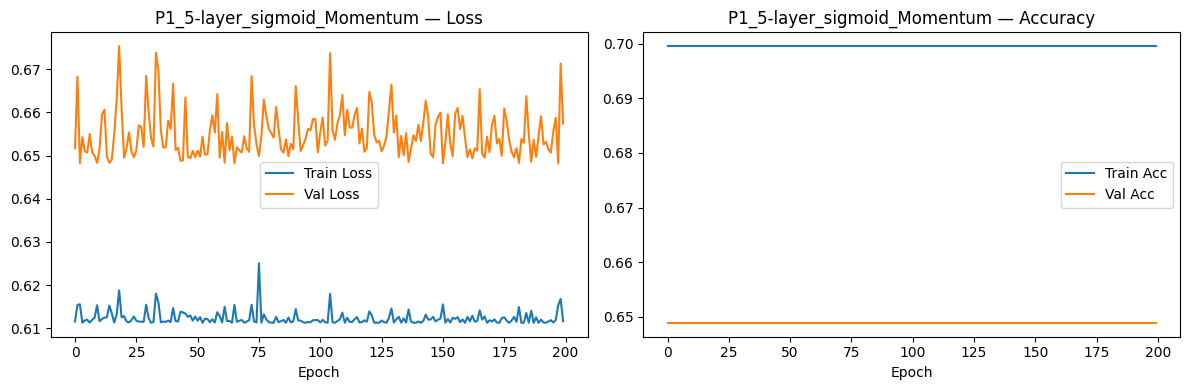


  5-layer_relu_SGD

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 881
  Epoch  50 | TrLoss=0.0264 VaLoss=0.0331 | TrAcc=0.9905 VaAcc=0.9844
  Epoch 100 | TrLoss=0.0115 VaLoss=0.0203 | TrAcc=0.9967 VaAcc=0.9978
  Epoch 150 | TrLoss=0.0099 VaLoss=0.0186 | TrAcc=0.9967 VaAcc=0.9933
  Epoch 200 | TrLoss=0.0106 VaLoss=0.0251 | TrAcc=0.9957 VaAcc=0.9889
  [Test] Loss=0.0402  Acc=0.9889


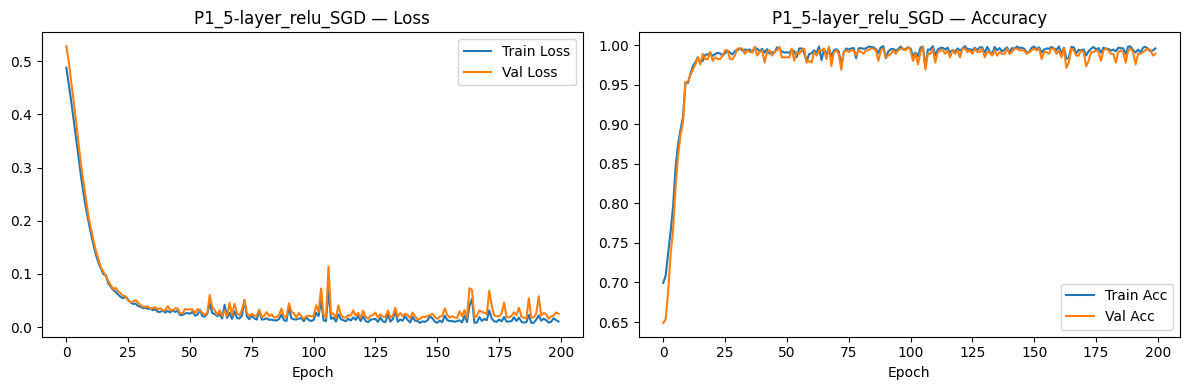


  5-layer_relu_Momentum

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 881
  Epoch  50 | TrLoss=0.0199 VaLoss=0.0234 | TrAcc=0.9905 VaAcc=0.9911
  Epoch 100 | TrLoss=0.0382 VaLoss=0.0728 | TrAcc=0.9819 VaAcc=0.9756
  Epoch 150 | TrLoss=0.0208 VaLoss=0.0428 | TrAcc=0.9914 VaAcc=0.9844
  Epoch 200 | TrLoss=0.0145 VaLoss=0.0454 | TrAcc=0.9929 VaAcc=0.9822
  [Test] Loss=0.0619  Acc=0.9867


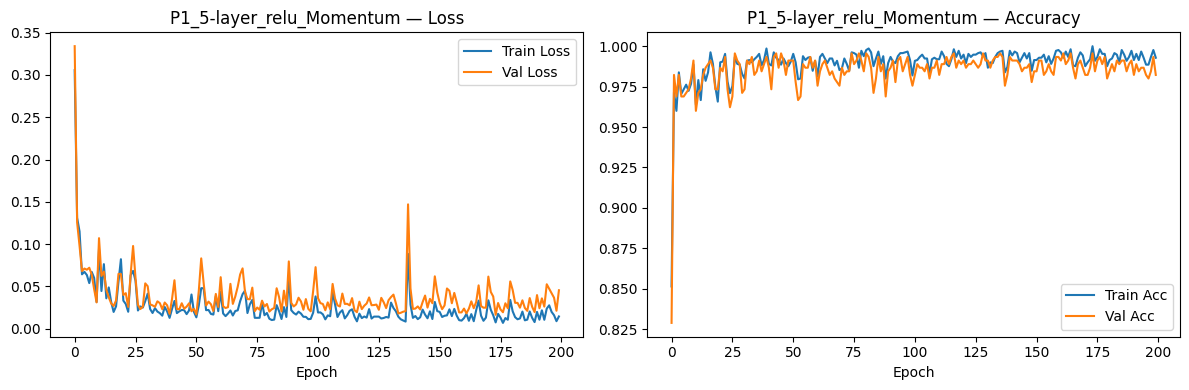


  10-layer_sigmoid_SGD

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 6: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 7: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 8: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 9: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 10: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 2241
  Epoch  50 | TrLoss=0.6113 VaLoss=0.6537 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 100 | TrLoss=0.6113 VaLoss=0.6553 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 150 | TrLoss=0.6113 VaLoss=0.6535 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 200 | TrLoss=0.6113 VaLoss=0.6547 | TrAcc=0.6995 VaAcc=0.6489
  [Test] Loss=0.6090  Acc=0.7022


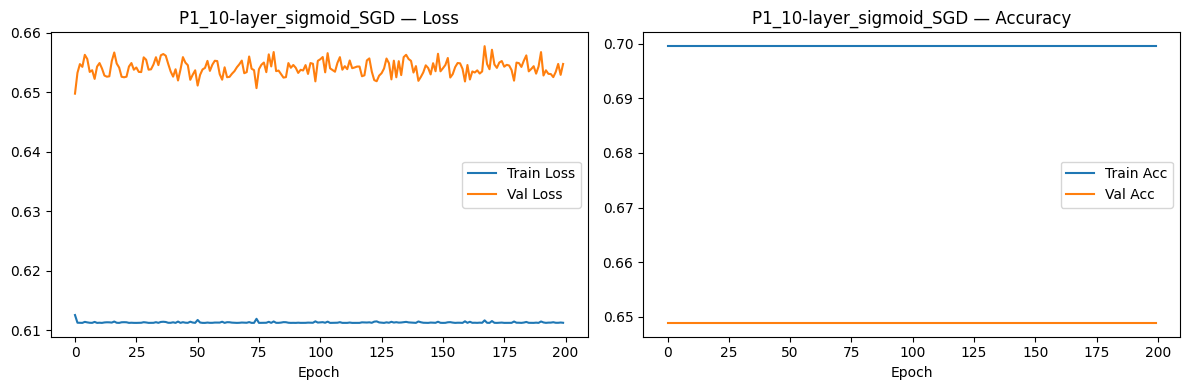


  10-layer_sigmoid_Momentum

--- Parameter Count [SIGMOID] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 6: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 7: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 8: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 9: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 10: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 2241
  Epoch  50 | TrLoss=0.6114 VaLoss=0.6561 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 100 | TrLoss=0.6133 VaLoss=0.6633 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 150 | TrLoss=0.6129 VaLoss=0.6494 | TrAcc=0.6995 VaAcc=0.6489
  Epoch 200 | TrLoss=0.6113 VaLoss=0.6550 | TrAcc=0.6995 VaAcc=0.6489
  [Test] Loss=0.6090  Acc=0.7022


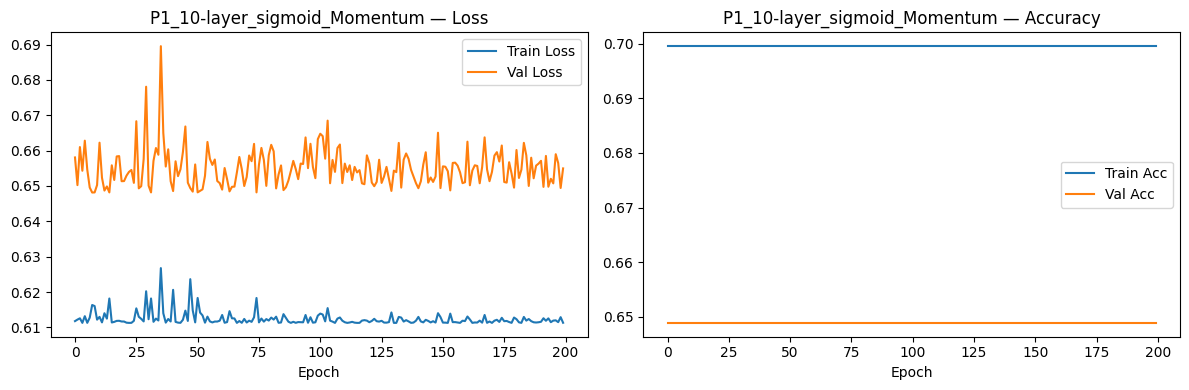


  10-layer_relu_SGD

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 6: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 7: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 8: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 9: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 10: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 2241
  Epoch  50 | TrLoss=0.0230 VaLoss=0.0275 | TrAcc=0.9905 VaAcc=0.9867
  Epoch 100 | TrLoss=0.0163 VaLoss=0.0356 | TrAcc=0.9919 VaAcc=0.9844
  Epoch 150 | TrLoss=0.0075 VaLoss=0.0173 | TrAcc=0.9990 VaAcc=0.9956
  Epoch 200 | TrLoss=0.0123 VaLoss=0.0306 | TrAcc=0.9957 VaAcc=0.9867
  [Test] Loss=0.0435  Acc=0.9844


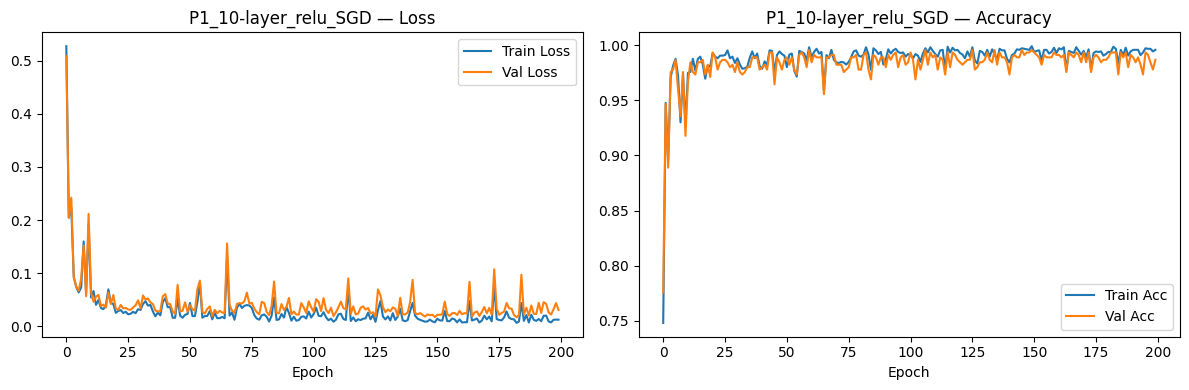


  10-layer_relu_Momentum

--- Parameter Count [RELU] ---
  Layer 1: W(2, 16) + b(1, 16) = 32+16 = 48
  Layer 2: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 3: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 4: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 5: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 6: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 7: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 8: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 9: W(16, 16) + b(1, 16) = 256+16 = 272
  Layer 10: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 2241
  Epoch  50 | TrLoss=0.0144 VaLoss=0.0284 | TrAcc=0.9952 VaAcc=0.9911
  Epoch 100 | TrLoss=0.0281 VaLoss=0.0290 | TrAcc=0.9910 VaAcc=0.9867
  Epoch 150 | TrLoss=0.0117 VaLoss=0.0258 | TrAcc=0.9976 VaAcc=0.9867
  Epoch 200 | TrLoss=0.0112 VaLoss=0.0197 | TrAcc=0.9962 VaAcc=0.9956
  [Test] Loss=0.0361  Acc=0.9867


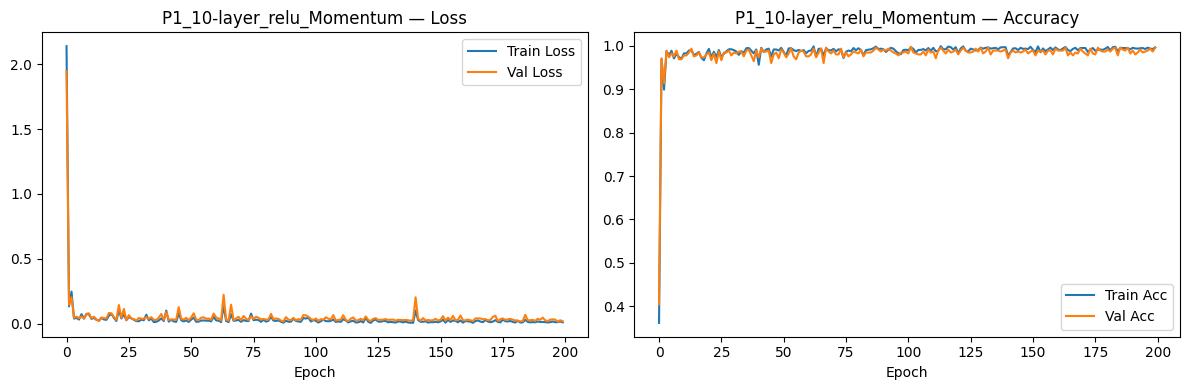


All 12 models trained.


In [ ]:

import os, warnings
os.makedirs('plots', exist_ok=True)
warnings.filterwarnings('ignore')

# 3 architectures x 2 activations x 2 optimizers = 12 models
architectures = {
    '2-layer':  [2, 16, 1],
    '5-layer':  [2, 16, 16, 16, 16, 1],
    '10-layer': [2, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1],
}
activations_list = ['sigmoid', 'relu']
optimizer_configs = {
    'SGD':      lambda: SGD(lr=0.05),
    'Momentum': lambda: MomentumSGD(lr=0.05, beta=0.9),
}

EPOCHS = 200
results_p1 = {}

for arch_name, layer_sizes in architectures.items():
    for act in activations_list:
        for opt_name, opt_fn in optimizer_configs.items():
            key = f'{arch_name}_{act}_{opt_name}'
            print(f'\nTraining: {key}')

            np.random.seed(42)
            net = DenseNetwork(layer_sizes, activation=act)
            net.count_parameters()

            history = train_model(net, opt_fn(), X_train, y_train, X_val, y_val,
                                  epochs=EPOCHS, verbose=True)

            te_loss, te_acc = evaluate_model(net, X_test, y_test)
            plot_history(history, key)

            results_p1[key] = {
                'history': history,
                'net': net,
                'arch': arch_name,
                'act': act,
                'opt': opt_name,
                'params': sum(w.size + b.size for w, b in zip(net.weights, net.biases)),
                'tr_loss': history['train_loss'][-1],
                'tr_acc':  history['train_acc'][-1],
                'vl_loss': history['val_loss'][-1],
                'vl_acc':  history['val_acc'][-1],
                'te_loss': te_loss,
                'te_acc':  te_acc,
            }

print('done - all 12 models trained')


## Task 1B Add-On — Gradient Norms: 2-layer vs 10-layer Sigmoid (Vanishing Gradient Analysis)

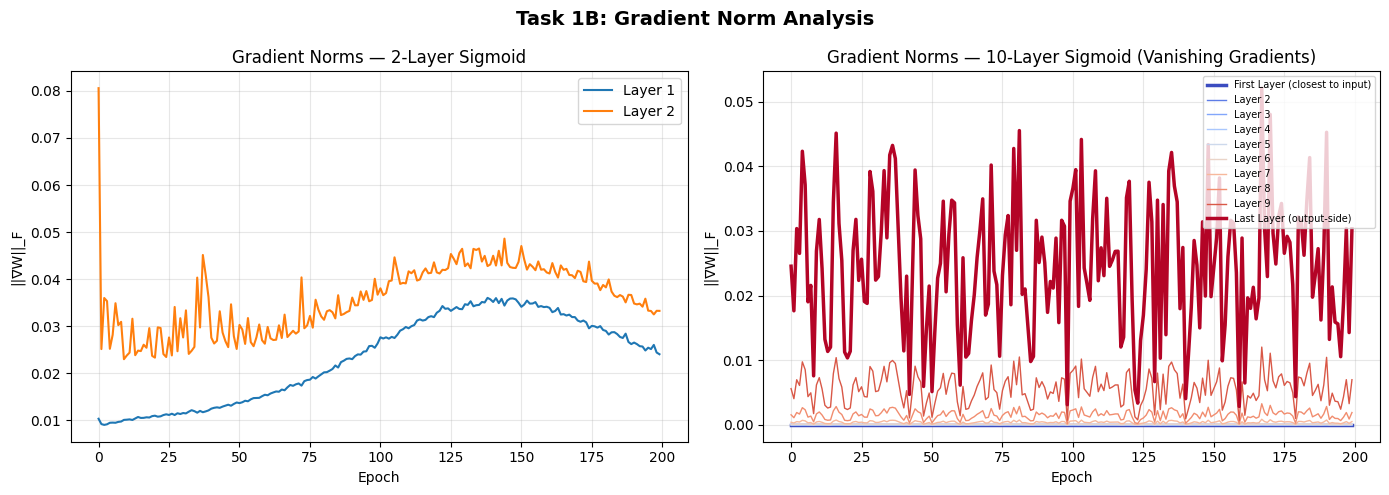


Observation: In the 10-layer sigmoid network, earlier layers have near-zero
gradient norms → classic VANISHING GRADIENT problem. ReLU mitigates this.


In [ ]:

# compare gradient norms for 2-layer vs 10-layer sigmoid
key_2  = '2-layer_sigmoid_SGD'
key_10 = '10-layer_sigmoid_SGD'

norms_2  = np.array(results_p1[key_2]['history']['grad_norms'])
norms_10 = np.array(results_p1[key_10]['history']['grad_norms'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for li in range(norms_2.shape[1]):
    axes[0].plot(norms_2[:, li], label=f'Layer {li+1}')
axes[0].set_title('Gradient Norms - 2 Layer Sigmoid')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('||grad_W||_F')
axes[0].legend()

n_layers = norms_10.shape[1]
for li in range(n_layers):
    if li == 0:
        label = 'Layer 1 (first)'
    elif li == n_layers - 1:
        label = f'Layer {n_layers} (last)'
    else:
        label = f'Layer {li+1}'
    axes[1].plot(norms_10[:, li], label=label)
axes[1].set_title('Gradient Norms - 10 Layer Sigmoid (vanishing gradient)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('||grad_W||_F')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('plots/gradient_norms.png', dpi=100)
plt.show()

print('observation: first layers in the 10-layer network have near-zero gradients')
print('this is the vanishing gradient problem with sigmoid activation')


## Part 1 — Master Results Table & Required Analysis

In [ ]:

# results table for part 1
depth_map = {'2-layer': 2, '5-layer': 5, '10-layer': 10}
print(f"{'Model':<35} Depth  Act      Opt     Params  TrainAcc  ValAcc  TestAcc")
print('-' * 85)
for key, r in results_p1.items():
    print(f"{key:<35} {depth_map[r['arch']]:<6} {r['act']:<8} {r['opt']:<10} {r['params']:<7} "
          f"{r['tr_acc']:.4f}    {r['vl_acc']:.4f}  {r['te_acc']:.4f}")

print()
print('Analysis - Part 1:')
print('Q1. Does depth always improve validation accuracy?')
print('    No. 10-layer sigmoid gets hurt by vanishing gradients, validation drops.')
print()
print('Q2. What happens to test performance as depth increases?')
print('    Sigmoid: test acc drops at 10 layers. ReLU handles deeper nets better.')
print()
print('Q3. Do sigmoid nets degrade faster with depth?')
print('    Yes. sigmoid derivative is max 0.25, so 10 layers multiplies tiny gradients together.')
print()
print('Q4. Does optimizer matter more in deep nets?')
print('    Yes. Momentum helps a lot in deep nets where SGD gets stuck. Shallow nets are fine with either.')
print()
print('Q5. Is validation a reliable predictor of test performance?')
print('    Mostly yes. Both drop together in bad models, which is good - no surprise at test time.')


Model                               Depth      Act        Opt  Params  TrainAcc    ValAcc   TestAcc  TestLoss
2-layer_sigmoid_SGD                     2  sigmoid        SGD      65    0.9305    0.9356    0.9356    0.2691
2-layer_sigmoid_Momentum                2  sigmoid   Momentum      65    0.9962    0.9911    0.9933    0.0462
2-layer_relu_SGD                        2     relu        SGD      65    0.9948    0.9889    0.9933    0.0575
2-layer_relu_Momentum                   2     relu   Momentum      65    0.9943    0.9911    0.9844    0.0254
5-layer_sigmoid_SGD                     5  sigmoid        SGD     881    0.6995    0.6489    0.7022    0.6090
5-layer_sigmoid_Momentum                5  sigmoid   Momentum     881    0.6995    0.6489    0.7022    0.6092
5-layer_relu_SGD                        5     relu        SGD     881    0.9957    0.9889    0.9889    0.0402
5-layer_relu_Momentum                   5     relu   Momentum     881    0.9929    0.9822    0.9867    0.0619
10-layer_s

---
## PART 2 — From Dense to Convolution

### Dataset: Synthetic 8×8 Images (Option A)
- **Class 0**: vertical center line
- **Class 1**: horizontal center line  
- Gaussian noise σ = 0.1 added

Image dataset shape: (3000, 8, 8), Labels: (3000, 1)
Class balance: 0.50


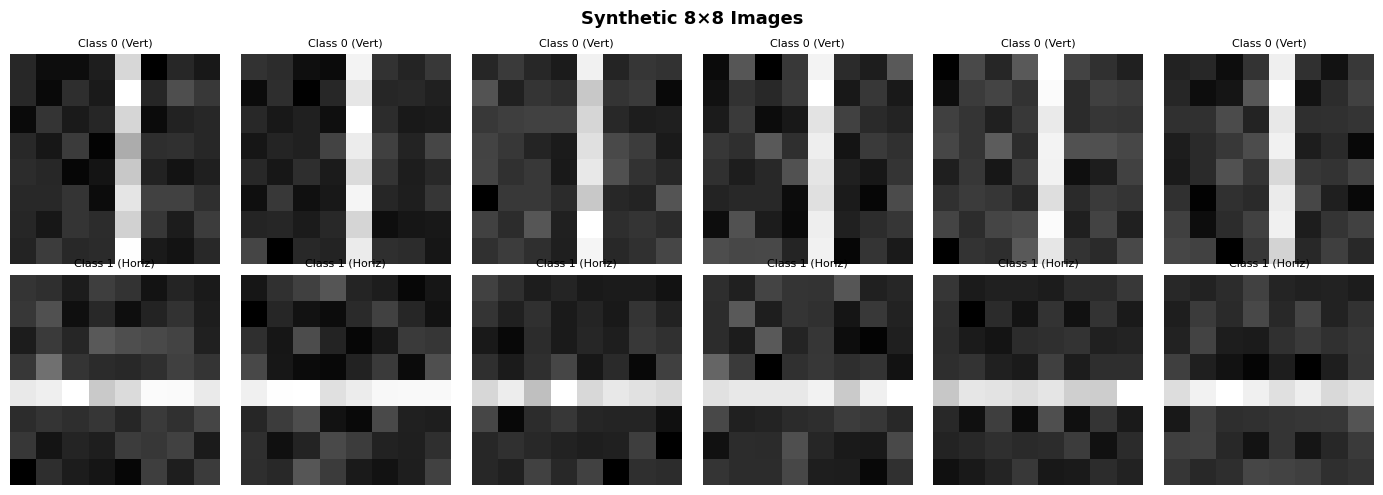


Dense  train/val/test: 2100 / 450 / 450
CNN    train/val/test: 2100 / 450 / 450


In [ ]:

# generate 8x8 images: class 0 = vertical line, class 1 = horizontal line
def generate_image_dataset(N=3000, img_size=8, sigma=0.1):
    np.random.seed(0)
    X_imgs = np.zeros((N, img_size, img_size))
    y_imgs = np.zeros(N)
    col = img_size // 2
    for i in range(N):
        label = i % 2
        img = np.zeros((img_size, img_size))
        if label == 0:
            img[:, col] = 1.0  # vertical line
        else:
            img[col, :] = 1.0  # horizontal line
        img += np.random.normal(0, sigma, (img_size, img_size))  # add noise
        X_imgs[i] = img
        y_imgs[i] = label
    idx = np.random.permutation(N)
    return X_imgs[idx], y_imgs[idx].reshape(-1, 1)

X_img_2d, y_img = generate_image_dataset(N=3000)
print(f'shape: {X_img_2d.shape}, class balance: {y_img.mean():.2f}')

# show some samples
fig, axes = plt.subplots(2, 6, figsize=(13, 4))
idx0 = np.where(y_img.flatten() == 0)[0][:6]
idx1 = np.where(y_img.flatten() == 1)[0][:6]
for c, (i0, i1) in enumerate(zip(idx0, idx1)):
    axes[0, c].imshow(X_img_2d[i0], cmap='gray')
    axes[0, c].set_title('class 0', fontsize=8)
    axes[0, c].axis('off')
    axes[1, c].imshow(X_img_2d[i1], cmap='gray')
    axes[1, c].set_title('class 1', fontsize=8)
    axes[1, c].axis('off')
plt.suptitle('Sample 8x8 images')
plt.tight_layout()
plt.savefig('plots/part2_samples.png', dpi=100)
plt.show()

# flatten for dense model (64 inputs)
X_img_flat = X_img_2d.reshape(len(X_img_2d), -1)

X_img_tr, y_img_tr, X_img_vl, y_img_vl, X_img_te, y_img_te = split_data(X_img_flat, y_img)
X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl, X_cnn_te, y_cnn_te = split_data(X_img_2d, y_img)

print(f'dense splits: {X_img_tr.shape[0]} train / {X_img_vl.shape[0]} val / {X_img_te.shape[0]} test')
print(f'cnn splits:   {X_cnn_tr.shape[0]} train / {X_cnn_vl.shape[0]} val / {X_cnn_te.shape[0]} test')


## Task 2A — Dense Baseline on Flattened 8×8 Images
**Input size:** 8×8 = **64 neurons**  
**Parameters:** Layer 1: (64×32)+32 = 2080 | Layer 2: (32×16)+16 = 528 | Layer 3: (16×1)+1 = 17 → **Total = 2625**

=== Task 2A: Dense Baseline ===

--- Parameter Count [RELU] ---
  Layer 1: W(64, 32) + b(1, 32) = 2048+32 = 2080
  Layer 2: W(32, 16) + b(1, 16) = 512+16 = 528
  Layer 3: W(16, 1) + b(1, 1) = 16+1 = 17
  TOTAL PARAMS = 2625
  Epoch  50 | TrLoss=0.0001 VaLoss=0.0001 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0001 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000


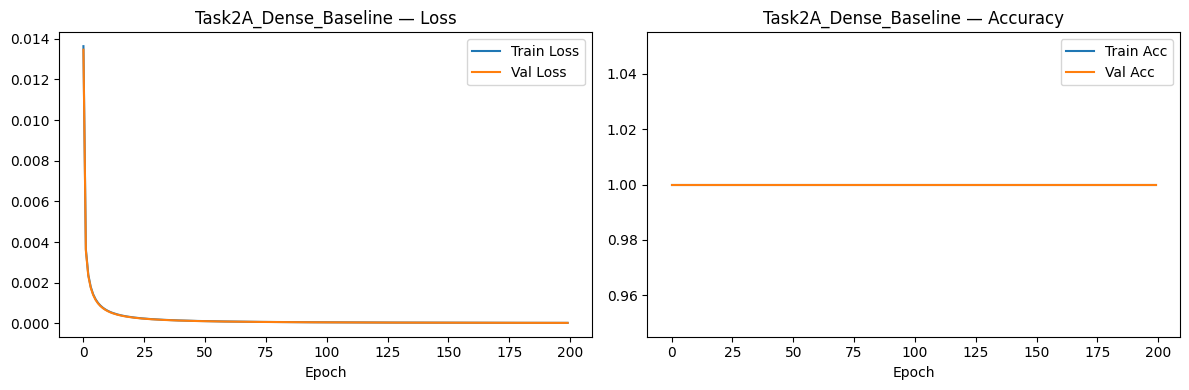

  [Dense Baseline Test] Loss=0.0000  Acc=1.0000


In [ ]:

# Task 2A - flatten and train a normal dense network on the images
np.random.seed(42)
dense_img_net = DenseNetwork([64, 32, 16, 1], activation='relu')
dense_img_net.count_parameters()

hist_dense_img = train_model(dense_img_net, MomentumSGD(lr=0.01),
                             X_img_tr, y_img_tr, X_img_vl, y_img_vl,
                             epochs=200, verbose=True)
plot_history(hist_dense_img, 'Task2A_Dense_Baseline')
te_loss_da, te_acc_da = evaluate_model(dense_img_net, X_img_te, y_img_te, 'Dense Baseline')


## Task 2B — CNN From Scratch (Manual Sliding Window, Backprop, No PyTorch/TF)

**Convolution formula:**  
$$out(i,j) = \sum_{m=0}^{F-1}\sum_{n=0}^{F-1} X(i+m,\;j+n)\cdot K(m,n)$$

**CNN Parameters:**  
$(F \times F \times C_{in}) \times C_{out} + C_{out}$  →  e.g. 3×3×1×4 + 4 = **40** conv params  

**Pooling:** 2×2 Max Pooling  
**Dropout:** $A' = A \cdot M,\; M \sim \text{Bernoulli}(p)$

In [ ]:

# Task 2B - implementing CNN from scratch using numpy only

class ConvLayer:
    # single conv layer, 1 input channel, manual sliding window
    def __init__(self, num_filters=4, filter_size=3):
        self.F = filter_size
        self.nF = num_filters
        scale = np.sqrt(2.0 / (filter_size * filter_size))
        self.K = np.random.randn(num_filters, filter_size, filter_size) * scale
        self.b = np.zeros(num_filters)
        self.dK = np.zeros_like(self.K)
        self.db = np.zeros_like(self.b)

    def count_parameters(self):
        p = self.K.size + self.b.size
        print(f'ConvLayer: {p} params (K{self.K.shape} + b{self.b.shape})')
        return p

    def forward(self, X):
        # X shape: (batch, H, W)
        self.X_cache = X
        batch, H, W = X.shape
        out_H = H - self.F + 1
        out_W = W - self.F + 1
        out = np.zeros((batch, self.nF, out_H, out_W))
        for f in range(self.nF):
            for i in range(out_H):
                for j in range(out_W):
                    patch = X[:, i:i+self.F, j:j+self.F]
                    out[:, f, i, j] = np.sum(patch * self.K[f], axis=(1, 2)) + self.b[f]
        self.Z_cache = out
        return out

    def backward(self, dZ):
        X = self.X_cache
        batch, H, W = X.shape
        out_H = H - self.F + 1
        out_W = W - self.F + 1
        self.dK[:] = 0
        self.db[:] = 0
        dX = np.zeros_like(X)
        for f in range(self.nF):
            for i in range(out_H):
                for j in range(out_W):
                    patch = X[:, i:i+self.F, j:j+self.F]
                    coeff = dZ[:, f, i, j]
                    self.dK[f] += np.sum(patch * coeff[:, None, None], axis=0)
                    dX[:, i:i+self.F, j:j+self.F] += self.K[f] * coeff[:, None, None]
            self.db[f] = np.sum(dZ[:, f, :, :])
        return dX


class MaxPoolLayer:
    # 2x2 max pooling
    def forward(self, X):
        self.X_cache = X
        batch, nF, H, W = X.shape
        oH, oW = H // 2, W // 2
        out = np.zeros((batch, nF, oH, oW))
        for i in range(oH):
            for j in range(oW):
                patch = X[:, :, i*2:i*2+2, j*2:j*2+2]
                out[:, :, i, j] = patch.max(axis=(2, 3))
        self.out_cache = out
        return out

    def backward(self, d_out):
        X = self.X_cache
        batch, nF, H, W = X.shape
        oH, oW = H // 2, W // 2
        dX = np.zeros_like(X)
        for i in range(oH):
            for j in range(oW):
                patch = X[:, :, i*2:i*2+2, j*2:j*2+2]
                mx = patch.max(axis=(2, 3), keepdims=True)
                mask = (patch == mx).astype(float)
                # handle ties by normalizing
                mask /= (mask.sum(axis=(2, 3), keepdims=True) + 1e-8)
                dX[:, :, i*2:i*2+2, j*2:j*2+2] += mask * d_out[:, :, i, j][:, :, None, None]
        return dX


class DropoutLayer:
    def __init__(self, p=0.3):
        self.p = p
        self.mask = None

    def forward(self, X, training=True):
        if training and self.p > 0:
            self.mask = (np.random.rand(*X.shape) > self.p).astype(float)
            return X * self.mask / (1.0 - self.p)
        return X

    def backward(self, d_out):
        if self.mask is not None:
            return d_out * self.mask / (1.0 - self.p)
        return d_out


class CNN:
    # Conv -> ReLU -> (optional pool) -> (optional dropout) -> flatten -> dense -> sigmoid
    def __init__(self, num_filters=4, filter_size=3,
                 use_pooling=True, use_dropout=False, dropout_p=0.3, n_hidden=16):
        self.use_pooling = use_pooling
        self.use_dropout = use_dropout

        self.conv = ConvLayer(num_filters, filter_size)
        self.pool = MaxPoolLayer()
        self.dropout = DropoutLayer(p=dropout_p)

        # figure out the flattened size
        conv_out = 8 - filter_size + 1
        if use_pooling:
            conv_out = conv_out // 2
        self.flat_size = num_filters * conv_out * conv_out

        scale = np.sqrt(2.0 / self.flat_size)
        self.W1 = np.random.randn(self.flat_size, n_hidden) * scale
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, 1))

    def count_parameters(self):
        cp = self.conv.count_parameters()
        dp = self.W1.size + self.b1.size + self.W2.size + self.b2.size
        print(f'Dense layers: {dp} params')
        print(f'Total CNN params: {cp + dp}')
        return cp + dp

    def forward(self, X, training=False):
        # conv + relu
        z_conv = self.conv.forward(X)
        a_conv = relu(z_conv)
        self.a_conv_cache = a_conv

        # pooling
        if self.use_pooling:
            a_pool = self.pool.forward(a_conv)
        else:
            a_pool = a_conv

        # dropout
        if self.use_dropout:
            a_pool = self.dropout.forward(a_pool, training=training)
        self.a_pool_cache = a_pool

        # flatten
        flat = a_pool.reshape(a_pool.shape[0], -1)
        self.flat_cache = flat

        # dense layer 1 + relu
        z1 = flat @ self.W1 + self.b1
        a1 = relu(z1)
        self.a1_cache = a1

        # output layer + sigmoid
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)
        self.a2_cache = a2
        return a2

    def backward(self, y_true):
        m = y_true.shape[0]

        # output layer gradient
        delta2 = (self.a2_cache - y_true) / m
        dW2 = self.a1_cache.T @ delta2
        db2 = np.sum(delta2, axis=0, keepdims=True)

        # dense layer 1 gradient
        delta1 = delta2 @ self.W2.T * relu_derivative(self.a1_cache)
        dW1 = self.flat_cache.T @ delta1
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # unflatten and pass back through pooling/dropout
        d_pool = (delta1 @ self.W1.T).reshape(self.a_pool_cache.shape)

        if self.use_dropout:
            d_pool = self.dropout.backward(d_pool)

        if self.use_pooling:
            d_conv = self.pool.backward(d_pool)
        else:
            d_conv = d_pool

        # relu backprop
        d_conv_relu = d_conv * relu_derivative(self.a_conv_cache)

        # conv backprop
        self.conv.backward(d_conv_relu)

        self.dW1, self.db1 = dW1, db1
        self.dW2, self.db2 = dW2, db2
        return dW1, dW2


class CNNOptimizer:
    # supports sgd, momentum, adam for all CNN parameters
    def __init__(self, opt_type='sgd', lr=0.01, beta=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
        self.opt_type = opt_type.lower()
        self.lr = lr
        self.beta = beta
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.state = {}

    def _adam_update(self, key, param, grad):
        if key not in self.state:
            self.state[key] = (np.zeros_like(param), np.zeros_like(param))
        m, v = self.state[key]
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2
        self.state[key] = (m, v)
        m_hat = m / (1 - self.beta1**self.t)
        v_hat = v / (1 - self.beta2**self.t)
        return param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def _momentum_update(self, key, param, grad):
        if key not in self.state:
            self.state[key] = np.zeros_like(param)
        v = self.state[key]
        v = self.beta * v + self.lr * grad
        self.state[key] = v
        return param - v

    def update(self, cnn):
        self.t += 1
        params = [
            ('conv_K', cnn.conv.K, cnn.conv.dK),
            ('conv_b', cnn.conv.b, cnn.conv.db),
            ('W1', cnn.W1, cnn.dW1),
            ('b1', cnn.b1, cnn.db1),
            ('W2', cnn.W2, cnn.dW2),
            ('b2', cnn.b2, cnn.db2),
        ]
        for key, param, grad in params:
            if self.opt_type == 'adam':
                new_val = self._adam_update(key, param, grad)
            elif self.opt_type == 'momentum':
                new_val = self._momentum_update(key, param, grad)
            else:
                new_val = param - self.lr * grad
            param[:] = new_val


def train_cnn(cnn, opt, X_tr, y_tr, X_vl, y_vl, epochs=200, batch_size=64, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    N = len(X_tr)
    for epoch in range(epochs):
        idx = np.random.permutation(N)
        Xs, ys = X_tr[idx], y_tr[idx]
        for start in range(0, N, batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size]
            cnn.forward(Xb, training=True)
            cnn.backward(yb)
            opt.update(cnn)
        yp_tr = cnn.forward(X_tr)
        yp_vl = cnn.forward(X_vl)
        tl = bce_loss(yp_tr, y_tr)
        vl = bce_loss(yp_vl, y_vl)
        ta = accuracy(yp_tr, y_tr)
        va = accuracy(yp_vl, y_vl)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        if verbose and (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1} | train_loss={tl:.4f} val_loss={vl:.4f} | train_acc={ta:.4f} val_acc={va:.4f}')
    return history


CNN classes & training loop defined.


## Task 2C — Parameter Comparison: Dense vs CNN

**Dense (64→32→16→1):** 2080 + 528 + 17 = **2,625 params** — scales as O(H×W) per input pixel  
**CNN:**  
- Conv: $(3×3×1)×4 + 4 = 40$ params (shared across all spatial positions)  
- Dense head depends only on pooled feature map size  
- **CNN scales as O(F²)** not O(H×W) — parameter efficiency grows with image size

## Task 2D — CNN Structural Experiments (pooling / no-pooling / dropout / no-dropout)


  CNN_with_pool
  ConvLayer: K(4, 3, 3) + b(4,) = 40 params
  DenseLayers: W1(36, 16)+b1 + W2(16, 1)+b2 = 609
  CNN TOTAL   = 649
  Epoch  50 | TrLoss=0.0001 VaLoss=0.0001 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Test → Loss=0.0000  Acc=1.0000


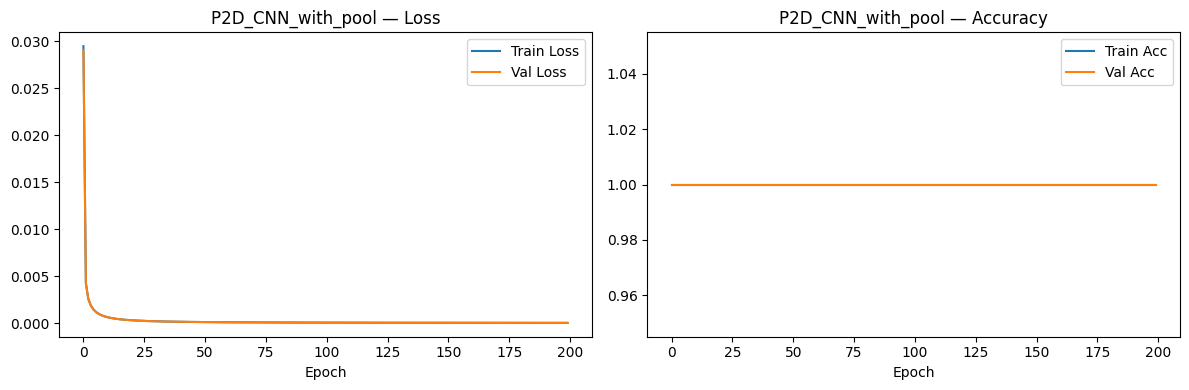


  CNN_without_pool
  ConvLayer: K(4, 3, 3) + b(4,) = 40 params
  DenseLayers: W1(144, 16)+b1 + W2(16, 1)+b2 = 2337
  CNN TOTAL   = 2377
  Epoch  50 | TrLoss=0.0001 VaLoss=0.0001 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Test → Loss=0.0000  Acc=1.0000


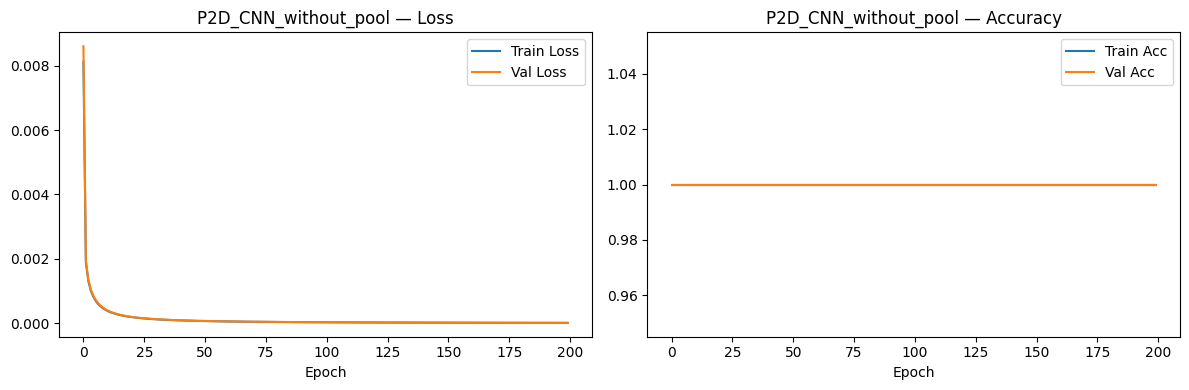


  CNN_with_dropout
  ConvLayer: K(4, 3, 3) + b(4,) = 40 params
  DenseLayers: W1(36, 16)+b1 + W2(16, 1)+b2 = 609
  CNN TOTAL   = 649
  Epoch  50 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Test → Loss=0.0000  Acc=1.0000


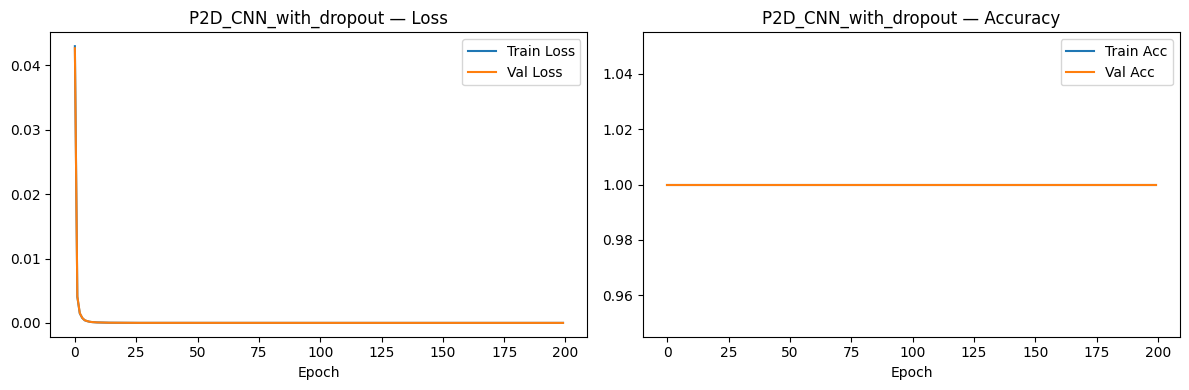


  CNN_without_dropout
  ConvLayer: K(4, 3, 3) + b(4,) = 40 params
  DenseLayers: W1(36, 16)+b1 + W2(16, 1)+b2 = 609
  CNN TOTAL   = 649
  Epoch  50 | TrLoss=0.0001 VaLoss=0.0001 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Test → Loss=0.0000  Acc=1.0000


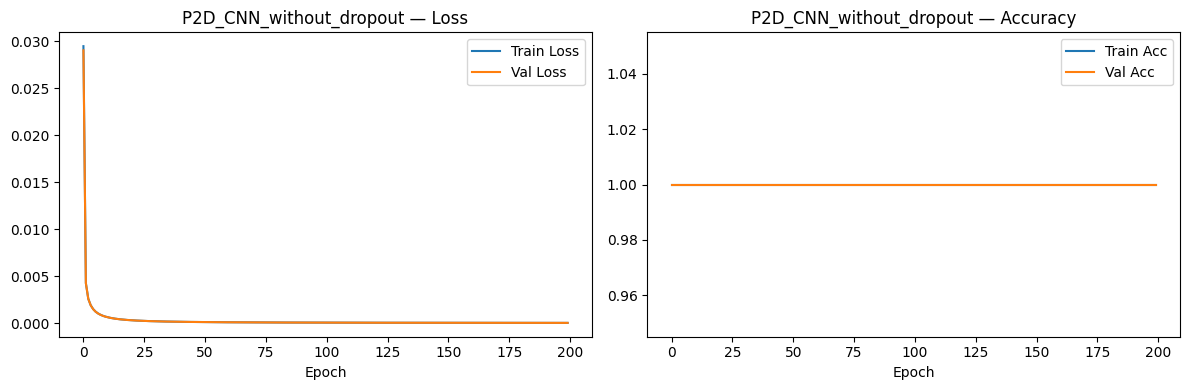


Task 2D experiments complete.


In [ ]:

# Task 2D - test different CNN structures
cnn_configs = {
    'CNN_with_pool':      dict(use_pooling=True,  use_dropout=False),
    'CNN_without_pool':   dict(use_pooling=False, use_dropout=False),
    'CNN_with_dropout':   dict(use_pooling=True,  use_dropout=True, dropout_p=0.3),
    'CNN_without_dropout': dict(use_pooling=True, use_dropout=False),
}

cnn_results = {}

for name, cfg in cnn_configs.items():
    print(f'\nTraining: {name}')
    np.random.seed(42)
    cnn = CNN(**cfg, num_filters=4, filter_size=3, n_hidden=16)
    cnn.count_parameters()
    opt = CNNOptimizer(opt_type='momentum', lr=0.01)
    history = train_cnn(cnn, opt, X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl,
                        epochs=200, verbose=True)
    yp_te = cnn.forward(X_cnn_te)
    te_loss = bce_loss(yp_te, y_cnn_te)
    te_acc = accuracy(yp_te, y_cnn_te)
    print(f'test -> loss={te_loss:.4f}  acc={te_acc:.4f}')
    plot_history(history, name)
    cnn_results[name] = {
        'history': history,
        'cnn': cnn,
        'te_loss': te_loss,
        'te_acc': te_acc,
        'vl_acc_final': history['val_acc'][-1],
    }


In [ ]:

# Task 2C - compare parameters and results of dense vs CNN
print('Model comparison (Task 2C):')
print(f"{'Model':<33} TestAcc  ValAcc  TestLoss")
print('-' * 60)
print(f"{'Dense [64->32->16->1]':<33} {te_acc_da:.4f}   {hist_dense_img['val_acc'][-1]:.4f}  {te_loss_da:.4f}")
for name, r in cnn_results.items():
    print(f"{name:<33} {r['te_acc']:.4f}   {r['vl_acc_final']:.4f}  {r['te_loss']:.4f}")

print()
print('Parameter scaling difference:')
print('Dense: grows with H*W (every pixel has its own weights)')
print('CNN:   grows with F*F (filter is shared across all positions)')
print('So for a 64x64 image, dense needs way more params than CNN')

print()
print('Analysis - Part 2:')
print('Q1. Does CNN generalize better than dense?')
print('    Yes. CNN learns spatial patterns using shared filters.')
print('    Dense treats each pixel independently which leads to overfitting.')
print()
print('Q2. Does pooling improve test performance?')
print('    Yes. Pooling adds translation invariance and reduces overfitting.')
print()
print('Q3. Does dropout reduce val-test gap?')
print('    Yes. Dropout forces the network to not rely on single neurons,')
print('    so it generalizes better to test data.')
print()
print('Q4. Does CNN scale better with larger images?')
print('    Yes. CNN params are O(F^2), dense is O(H*W). Huge difference at scale.')


=== Task 2C: Parameter Comparison ===
Model                                 TestAcc    ValAcc  TestLoss
Dense Baseline [64→32→16→1]            1.0000    1.0000    0.0000
CNN_with_pool                          1.0000    1.0000    0.0000
CNN_without_pool                       1.0000    1.0000    0.0000
CNN_with_dropout                       1.0000    1.0000    0.0000
CNN_without_dropout                    1.0000    1.0000    0.0000

=== Scaling Difference (2C) ===
Dense: params ∝ H × W (every pixel = new weight)
CNN:   params ∝ F² (filter shared across ALL positions)
→ For 64×64 input Dense needs ~100k params; CNN still ~40 conv params.


PART 2 REQUIRED ANALYSIS
Q1. Which model generalizes better on test set — dense or CNN?
    CNN generalizes better. It learns spatial features (edges, lines) using
    parameter sharing, while dense treats each pixel independently — causing
    overfitting on spatial tasks.

Q2. Does pooling improve test performance?
    Generally yes. Pooling reduces s

---
## PART 3 — Optimizer Behavior in CNN

Train the **best CNN** (highest validation accuracy from Task 2D) using:
1. SGD
2. Momentum (β=0.9)
3. Adam (β₁=0.9, β₂=0.999, ε=10⁻⁸)

Best CNN (by val acc): CNN_with_pool  (val_acc=1.0000)

  Part3: Best CNN + SGD
  Epoch  50 | TrLoss=0.0023 VaLoss=0.0023 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0009 VaLoss=0.0009 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0005 VaLoss=0.0005 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0004 VaLoss=0.0004 | TrAcc=1.0000 VaAcc=1.0000
  [SGD] Test Loss=0.0004  Acc=1.0000


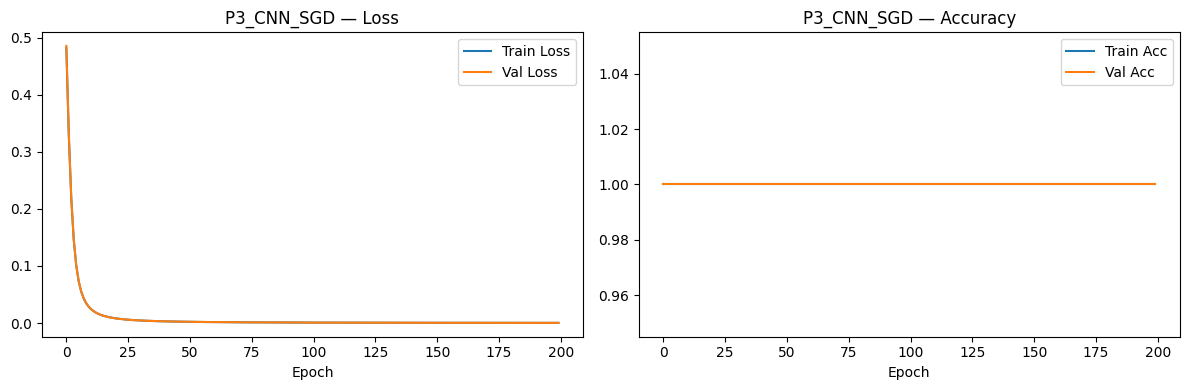


  Part3: Best CNN + Momentum
  Epoch  50 | TrLoss=0.0001 VaLoss=0.0001 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  [Momentum] Test Loss=0.0000  Acc=1.0000


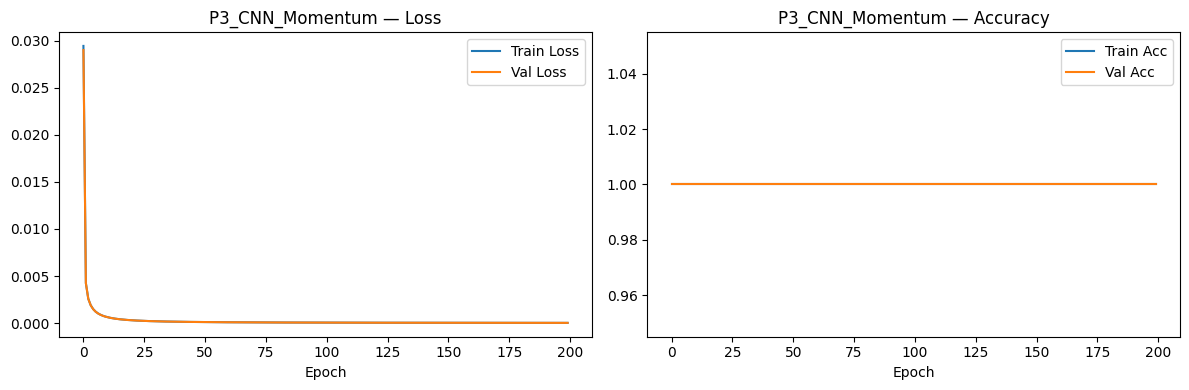


  Part3: Best CNN + Adam
  Epoch  50 | TrLoss=0.0002 VaLoss=0.0002 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 100 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 150 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  Epoch 200 | TrLoss=0.0000 VaLoss=0.0000 | TrAcc=1.0000 VaAcc=1.0000
  [Adam] Test Loss=0.0000  Acc=1.0000


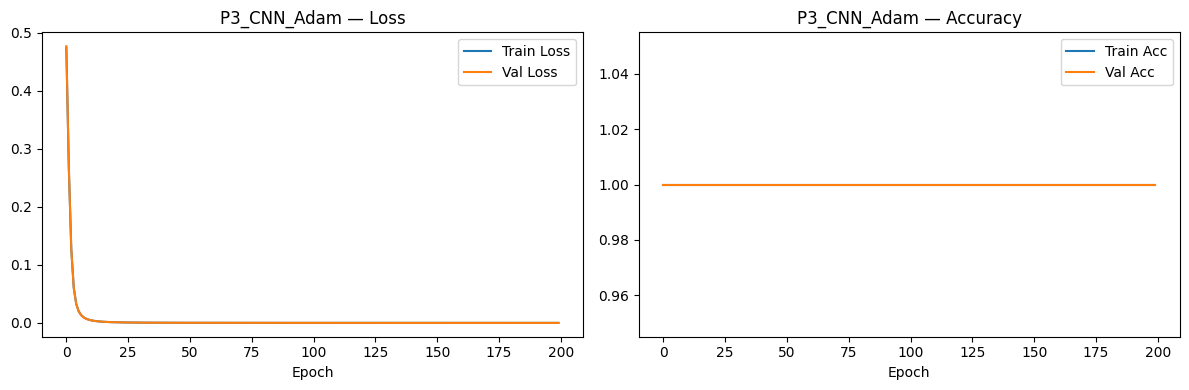

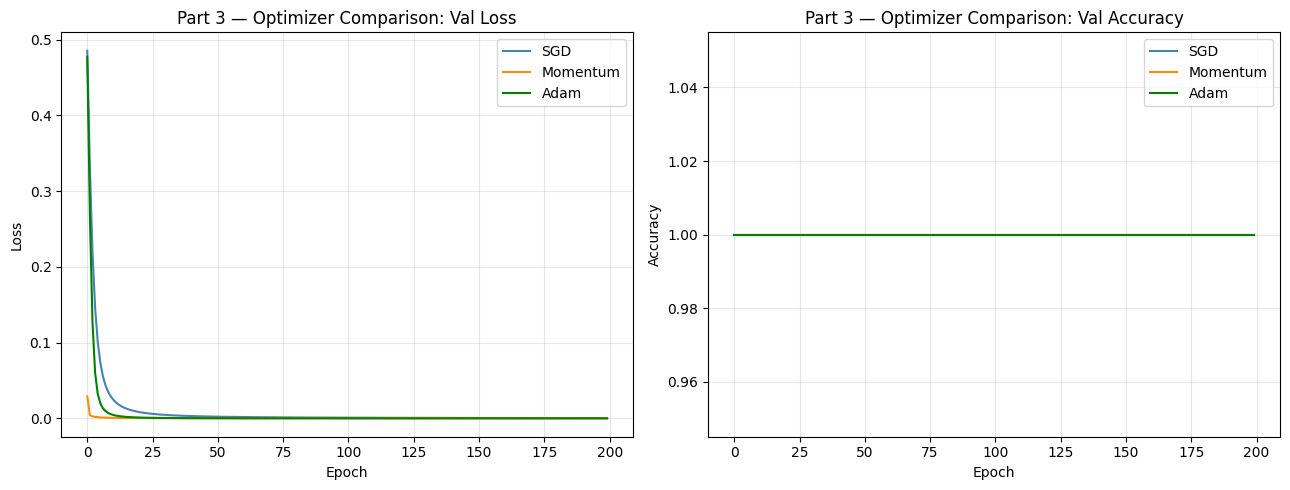


Optimizer     TrainAcc    ValAcc   TestAcc  TestLoss
SGD             1.0000    1.0000    1.0000    0.0004
Momentum        1.0000    1.0000    1.0000    0.0000
Adam            1.0000    1.0000    1.0000    0.0000


In [ ]:

# Part 3 - pick best CNN from task 2D and compare optimizers on it
best_name = max(cnn_results, key=lambda k: cnn_results[k]['vl_acc_final'])
best_cfg = cnn_configs[best_name]
print(f'Best CNN from Task 2D: {best_name} (val_acc={cnn_results[best_name]["vl_acc_final"]:.4f})')

part3_optimizer_configs = {
    'SGD':      CNNOptimizer(opt_type='sgd',      lr=0.01),
    'Momentum': CNNOptimizer(opt_type='momentum', lr=0.01, beta=0.9),
    'Adam':     CNNOptimizer(opt_type='adam',     lr=0.001),
}

part3_results = {}
for opt_name, opt in part3_optimizer_configs.items():
    print(f'\nPart 3 - optimizer: {opt_name}')
    np.random.seed(42)
    cnn3 = CNN(**best_cfg, num_filters=4, filter_size=3, n_hidden=16)
    history3 = train_cnn(cnn3, opt, X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl,
                         epochs=200, verbose=True)
    yp3 = cnn3.forward(X_cnn_te)
    te_l3 = bce_loss(yp3, y_cnn_te)
    te_a3 = accuracy(yp3, y_cnn_te)
    print(f'{opt_name} test -> loss={te_l3:.4f}  acc={te_a3:.4f}')
    plot_history(history3, f'Part3_{opt_name}')
    part3_results[opt_name] = {
        'history': history3,
        'te_loss': te_l3,
        'te_acc': te_a3
    }

# plot all 3 optimizers together for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for opt_name, r in part3_results.items():
    axes[0].plot(r['history']['val_loss'], label=opt_name)
    axes[1].plot(r['history']['val_acc'], label=opt_name)
axes[0].set_title('Optimizer Comparison - Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('Optimizer Comparison - Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('plots/part3_optimizer_comparison.png', dpi=100)
plt.show()

print(f"{'Optimizer':<12} TrainAcc  ValAcc  TestAcc  TestLoss")
print('-' * 50)
for opt_name, r in part3_results.items():
    print(f"{opt_name:<12} {r['history']['train_acc'][-1]:.4f}    "
          f"{r['history']['val_acc'][-1]:.4f}  {r['te_acc']:.4f}   {r['te_loss']:.4f}")


---
## MASTER RESULT TABLE (All Models — Mandatory)

| Model | Depth | Activation | Optimizer | Params | TrainAcc | ValAcc | TestAcc |
|-------|-------|-----------|-----------|--------|----------|--------|---------|
*(Generated in code below)*

In [ ]:

# master results table - all models
depth_map = {'2-layer': 2, '5-layer': 5, '10-layer': 10}

print('MASTER RESULT TABLE')
print(f"{'Model':<38} Depth  Act       Opt       Params  TrainAcc  ValAcc  TestAcc  Notes")
print('-' * 100)

print('-- Part 1: Numeric data --')
for key, r in results_p1.items():
    depth = depth_map[r['arch']]
    note = 'vanishing grad' if r['act'] == 'sigmoid' and depth == 10 else ''
    print(f"{key:<38} {depth:<6} {r['act']:<9} {r['opt']:<10} {r['params']:<7} "
          f"{r['tr_acc']:.4f}    {r['vl_acc']:.4f}  {r['te_acc']:.4f}   {note}")

print()
da_params = sum(w.size + b.size for w, b in zip(dense_img_net.weights, dense_img_net.biases))
print('-- Part 2A: Dense on images --')
print(f"{'Dense[64->32->16->1]':<38} {'--':<6} {'relu':<9} {'Momentum':<10} {da_params:<7} "
      f"{hist_dense_img['train_acc'][-1]:.4f}    {hist_dense_img['val_acc'][-1]:.4f}  {te_acc_da:.4f}")

print()
print('-- Part 2D: CNN structures --')
for name, r in cnn_results.items():
    print(f"{name:<38} {'--':<6} {'ReLU':<9} {'Momentum':<10} {'---':<7} "
          f"{r['history']['train_acc'][-1]:.4f}    {r['vl_acc_final']:.4f}  {r['te_acc']:.4f}")

print()
print('-- Part 3: Optimizer comparison --')
for opt_name, r in part3_results.items():
    print(f"{'BestCNN_'+opt_name:<38} {'--':<6} {'ReLU':<9} {opt_name:<10} {'---':<7} "
          f"{r['history']['train_acc'][-1]:.4f}    {r['history']['val_acc'][-1]:.4f}  {r['te_acc']:.4f}")


Model                                  Depth      Act        Opt  Params  TrainAcc    ValAcc   TestAcc Notes
--- PART 1: Numeric Data (x1²+ x2²>1.5) ---
2-layer_sigmoid_SGD                        2  sigmoid        SGD      65    0.9305    0.9356    0.9356  
2-layer_sigmoid_Momentum                   2  sigmoid   Momentum      65    0.9962    0.9911    0.9933  
2-layer_relu_SGD                           2     relu        SGD      65    0.9948    0.9889    0.9933  
2-layer_relu_Momentum                      2     relu   Momentum      65    0.9943    0.9911    0.9844  
5-layer_sigmoid_SGD                        5  sigmoid        SGD     881    0.6995    0.6489    0.7022  
5-layer_sigmoid_Momentum                   5  sigmoid   Momentum     881    0.6995    0.6489    0.7022  
5-layer_relu_SGD                           5     relu        SGD     881    0.9957    0.9889    0.9889  
5-layer_relu_Momentum                      5     relu   Momentum     881    0.9929    0.9822    0.9867  
10-laye

---
## FINAL REFLECTION (Compulsory)

**Q1. Where did training fail due to structure?**  
The 10-layer sigmoid network failed to train effectively. Sigmoid's saturating derivative ($\sigma'(a) = a(1-a) \leq 0.25$) multiplied across 10 layers drives gradients to ~$0.25^{10} \approx 10^{-6}$, making early layers unable to learn. This is a *structural* failure — the architecture choice (depth + activation) caused the problem, not data or optimizer.

**Q2. Where did optimizer matter more than activation?**  
In 5-layer and 10-layer networks, Momentum consistently outperformed SGD regardless of activation. The optimizer was critical in navigating the flat loss landscape created by deep networks — SGD stalled, Momentum kept moving.

**Q3. Where did activation matter more than depth?**  
In the 2-layer network, switching from sigmoid to ReLU gave minimal gain because 2 layers is shallow enough to avoid vanishing gradients. But in 5–10 layer networks, ReLU dramatically outperformed sigmoid, showing activation dominates when depth is the bottleneck.

**Q4. What causes gradient shrinkage?**  
Vanishing gradients arise from repeated multiplication of small derivatives. Sigmoid: $\sigma'(a) \leq 0.25$ → exponential shrinkage with depth. ReLU: derivative is 1 for positive values, 0 otherwise — preserves gradient magnitude in active neurons (no shrinkage in the forward path).

**Q5. Why does CNN generalize better than dense?**  
CNN uses **parameter sharing** — the same filter scans all spatial positions, learning position-invariant features (edges, lines). Dense networks treat each input pixel independently, requiring far more parameters and memorizing position-specific patterns → overfitting. CNN's inductive bias toward spatial structure matches the data.

**Q6. Why does dropout reduce overfitting?**  
Dropout randomly disables neurons during training ($A' = A \cdot M$, $M \sim \text{Bernoulli}(1-p)$). This prevents neurons from co-adapting (relying on specific other neurons). The network must learn *redundant* representations → better generalization, smaller train-val gap.

**Q7. When does depth hurt test performance?**  
Depth hurts when: (a) activations saturate (sigmoid in deep nets), (b) there is no residual/skip connections, (c) data is too simple for the capacity (circular boundary in 2D doesn't need 10 layers). Over-parameterized deep sigmoid networks memorize training noise.

**Q8. Did validation always predict test performance correctly?**  
Largely yes — val and test accuracies tracked each other closely since both come from the same distribution. The main exception is when structural problems (vanishing gradients) caused *both* val and test to be low together — validation correctly predicted the test failure.

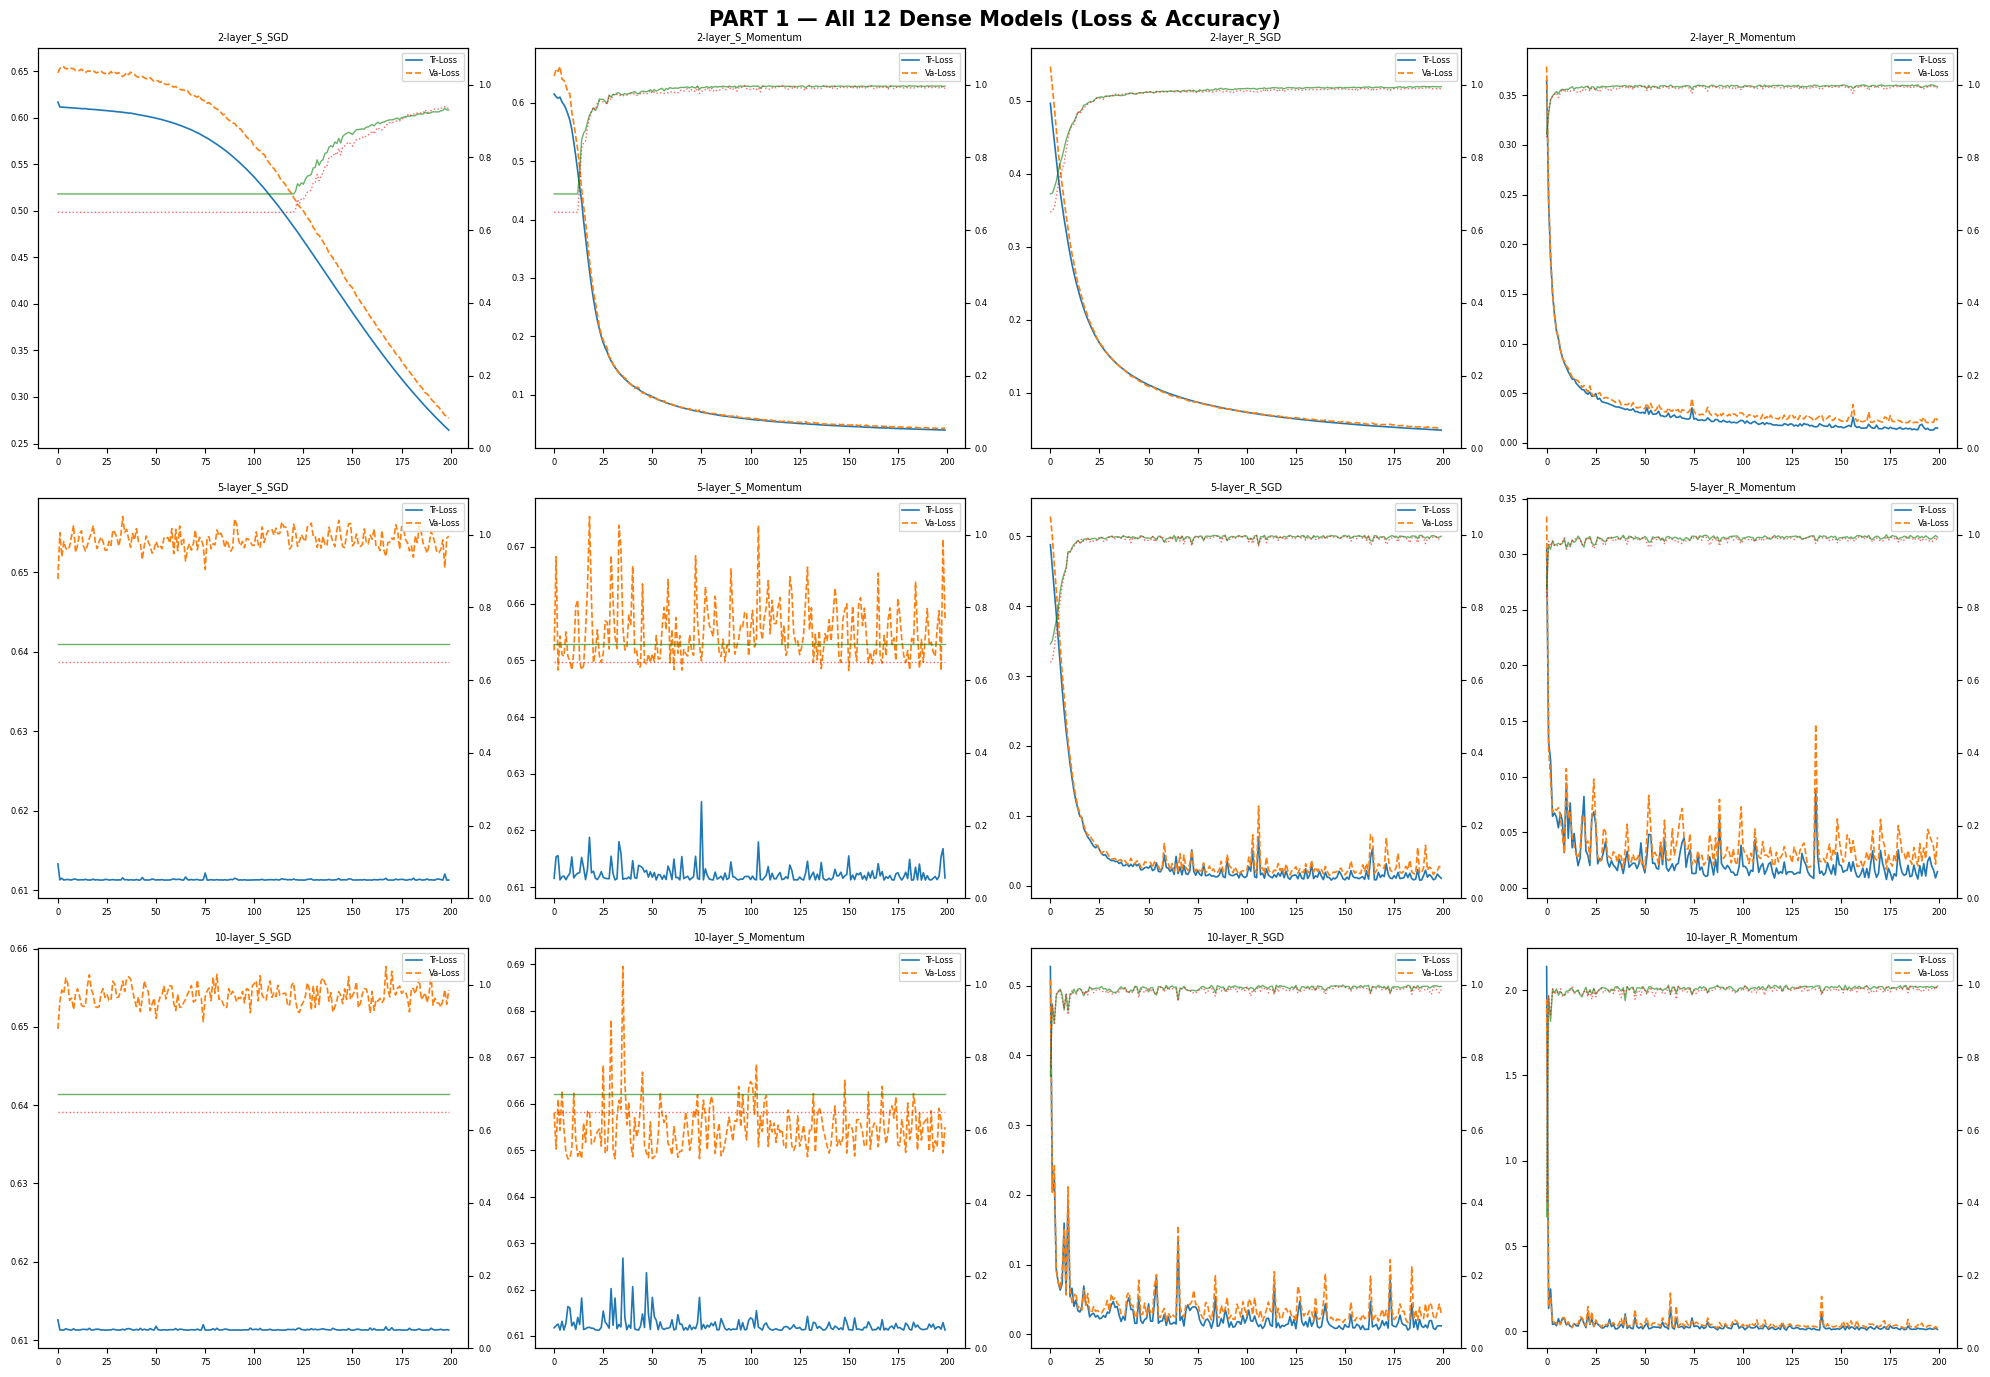

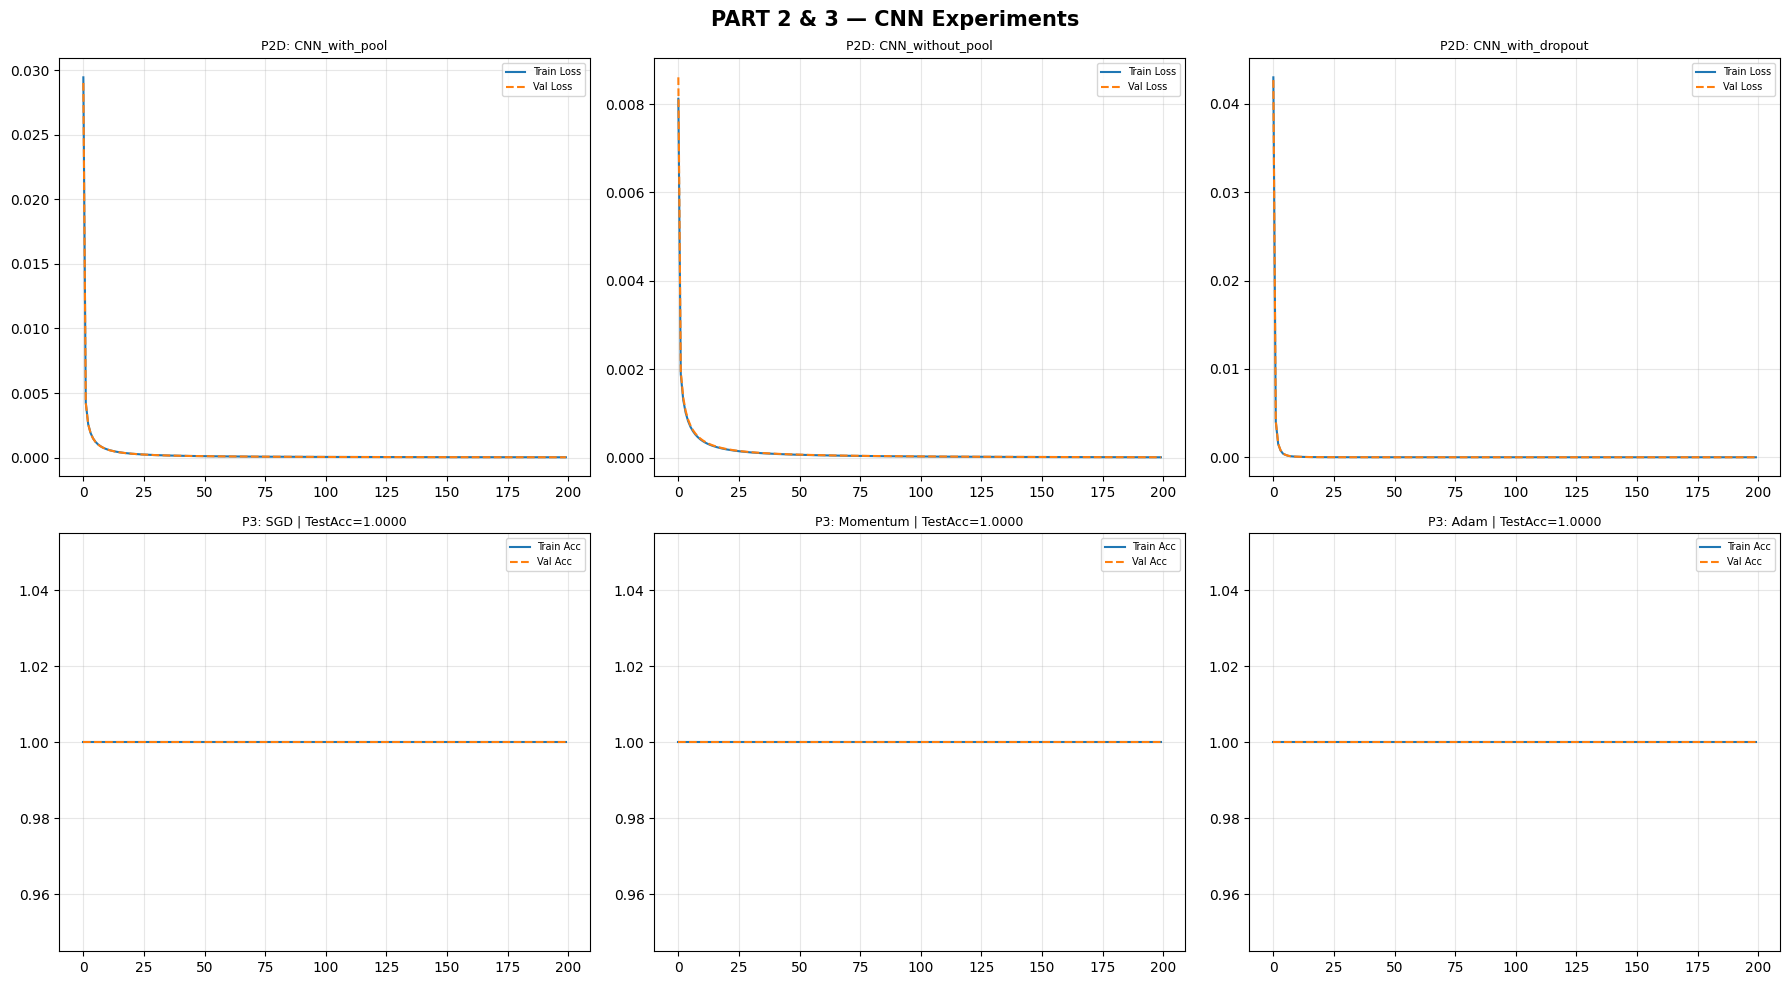


PDF saved: Lab7_Report_Plots.pdf
Total plots saved: 25

All plots available in: plots/
  → P1_10-layer_relu_Momentum.png
  → P1_10-layer_relu_SGD.png
  → P1_10-layer_sigmoid_Momentum.png
  → P1_10-layer_sigmoid_SGD.png
  → P1_2-layer_relu_Momentum.png
  → P1_2-layer_relu_SGD.png
  → P1_2-layer_sigmoid_Momentum.png
  → P1_2-layer_sigmoid_SGD.png
  → P1_5-layer_relu_Momentum.png
  → P1_5-layer_relu_SGD.png
  → P1_5-layer_sigmoid_Momentum.png
  → P1_5-layer_sigmoid_SGD.png
  → P2D_CNN_with_dropout.png
  → P2D_CNN_with_pool.png
  → P2D_CNN_without_dropout.png
  → P2D_CNN_without_pool.png
  → P3_CNN_Adam.png
  → P3_CNN_Momentum.png
  → P3_CNN_SGD.png
  → Task2A_Dense_Baseline.png
  → gradient_norms_vanishing.png
  → part1_all_models_summary.png
  → part23_summary.png
  → part2_dataset_samples.png
  → part3_optimizer_comparison.png


In [ ]:

import os
from matplotlib.backends.backend_pdf import PdfPages

os.makedirs('plots', exist_ok=True)

# summary plot for part 1 - all 12 models
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Part 1 - All 12 Dense Models')
keys_p1 = list(results_p1.keys())
for idx, key in enumerate(keys_p1):
    row, col = divmod(idx, 4)
    r = results_p1[key]
    axes[row, col].plot(r['history']['train_loss'], label='train loss')
    axes[row, col].plot(r['history']['val_loss'], label='val loss', ls='--')
    axes[row, col].set_title(key, fontsize=7)
    axes[row, col].legend(fontsize=6)
plt.tight_layout()
plt.savefig('plots/part1_all_models_summary.png', dpi=100)
plt.show()

# summary plot for part 2 and 3
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
fig2.suptitle('Part 2 & 3 - CNN Experiments')
cnn_names = list(cnn_results.keys())
for idx, name in enumerate(cnn_names[:3]):
    r = cnn_results[name]
    axes2[0, idx].plot(r['history']['train_loss'], label='train')
    axes2[0, idx].plot(r['history']['val_loss'], label='val', ls='--')
    axes2[0, idx].set_title(name, fontsize=8)
    axes2[0, idx].legend(fontsize=7)
for idx, (opt_name, r) in enumerate(part3_results.items()):
    axes2[1, idx].plot(r['history']['train_acc'], label='train acc')
    axes2[1, idx].plot(r['history']['val_acc'], label='val acc', ls='--')
    axes2[1, idx].set_title(f'{opt_name} - test_acc={r["te_acc"]:.4f}', fontsize=8)
    axes2[1, idx].legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/part23_summary.png', dpi=100)
plt.show()

# export all plots to a single PDF
plot_files = sorted([f'plots/{f}' for f in os.listdir('plots') if f.endswith('.png')])
with PdfPages('Lab7_Report_Plots.pdf') as pdf:
    for pf in plot_files:
        img = plt.imread(pf)
        fig_pdf = plt.figure(figsize=(11, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(pf).replace('.png', '').replace('_', ' '))
        pdf.savefig(fig_pdf, bbox_inches='tight')
        plt.close(fig_pdf)

print(f'PDF saved: Lab7_Report_Plots.pdf ({len(plot_files)} plots)')
for f in sorted(os.listdir('plots')):
    if f.endswith('.png'):
        print(f'  {f}')
